# NYSE Stock Price Forecasting
## Time Series Prediction with GRU and LSTM

This project builds a deep learning model to forecast stock closing prices using a hybrid GRU and LSTM architecture trained on historical NYSE price data. The model is trained on Adobe Systems (ADBE) closing prices spanning 2010 to 2016, then evaluated on a held-out test set by comparing predicted vs. actual price trajectories.

Recurrent neural networks are well-suited to financial time series because they maintain hidden state across time steps, allowing the model to learn sequential patterns and temporal dependencies that traditional regression models cannot capture.

### Dataset

The [NYSE Prices dataset](https://www.kaggle.com/datasets/dgawlik/nyse) contains 851,264 daily price records across 501 S&P 500 companies from 2010 to 2016. Two files are used:

- **prices.csv:** daily open, close, low, high, and volume per ticker symbol
- **securities.csv:** company name and sector metadata per ticker

### Architecture

The model uses a GRU layer followed by an LSTM layer, both with 256 units, with Dropout regularization between layers to reduce overfitting. A Dense output layer produces the single-step price forecast.

### Workflow

**Part 1:** Dataset exploration: price records, ticker symbols, and company metadata

**Part 2:** Company selection and stock price visualization

**Part 3:** Feature scaling and sequence construction

**Part 4:** Model architecture: GRU, LSTM, Dropout, Dense

**Part 5:** Training with callbacks: ModelCheckpoint and ReduceLROnPlateau

**Part 6:** Evaluation: MSE/RMSE scores and predicted vs. actual price plot

### Stack

Python, NumPy, Pandas, Matplotlib, scikit-learn, Keras (TensorFlow)

---
## Part 1: Setup and Dataset Exploration

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

### Price Data

In [ ]:
df = pd.read_csv('prices.csv', header=0)
print(f'Price records: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
5,2016-01-12 00:00:00,WLTW,115.510002,115.550003,114.500000,116.059998,1098000.0
6,2016-01-13 00:00:00,WLTW,116.459999,112.849998,112.589996,117.070000,949600.0
7,2016-01-14 00:00:00,WLTW,113.510002,114.379997,110.050003,115.029999,785300.0
8,2016-01-15 00:00:00,WLTW,113.330002,112.529999,111.919998,114.879997,1093700.0
9,2016-01-19 00:00:00,WLTW,113.660004,110.379997,109.870003,115.870003,1523500.0


In [ ]:
print(f'Date range: {df.date.min()} to {df.date.max()}')
print(f'Total ticker symbols: {df.symbol.nunique()}')
print(f'Missing values:\n{df.isnull().sum()}')

date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

In [ ]:
#gives the details of each columns of the dataset like mean, max etc
df.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


### Company Metadata

In [ ]:
comp_info = pd.read_csv('securities.csv')
print(f'Companies: {comp_info.shape[0]} records')
comp_info.head()

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",31-03-1964,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",31-12-2012,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",06-07-2011,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",31-08-2015,718877
5,AYI,Acuity Brands Inc,reports,Industrials,Electrical Components & Equipment,"Atlanta, Georgia",03-05-2016,1144215
6,ADBE,Adobe Systems Inc,reports,Information Technology,Application Software,"San Jose, California",05-05-1997,796343
7,AAP,Advance Auto Parts,reports,Consumer Discretionary,Automotive Retail,"Roanoke, Virginia",09-07-2015,1158449
8,AES,AES Corp,reports,Utilities,Independent Power Producers & Energy Traders,"Arlington, Virginia",NaN,874761
9,AET,Aetna Inc,reports,Health Care,Managed Health Care,"Hartford, Connecticut",30-06-1976,1122304


In [ ]:
print(f'Unique ticker symbols: {comp_info["Ticker symbol"].nunique()}')
print(f'Sectors covered:')
print(comp_info['GICS Sector'].value_counts().to_string())

---
## Part 2: Company Selection and Stock Price Visualization

Six representative companies are selected across sectors to visualize historical opening and closing price trajectories. Adobe Systems is selected as the target company for forecasting due to its strong upward trend and consistent data coverage.

In [ ]:
target_companies = [
    'Yahoo Inc.', 'Xerox Corp.', 'Adobe Systems Inc',
    'Microsoft Corp.', 'Facebook', 'Goldman Sachs Group'
]

comp_plot = comp_info.loc[
    comp_info['Security'].isin(target_companies),
    'Ticker symbol'
]['Ticker symbol']

print('Selected tickers:', list(comp_plot))

6      ADBE
181      FB
212      GS
306    MSFT
496     XRX
500    YHOO
Name: Ticker symbol, dtype: object


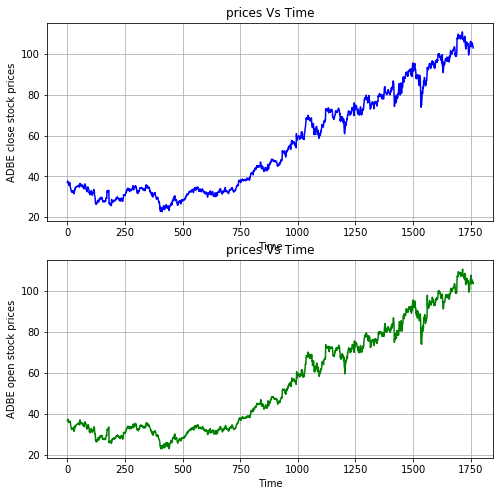

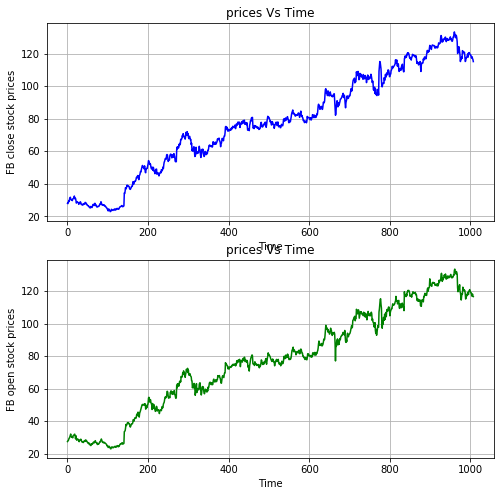

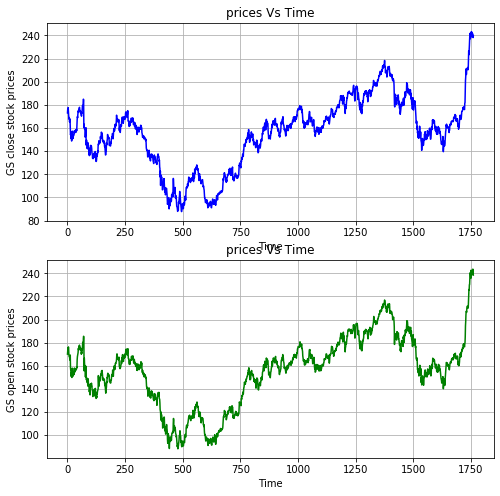

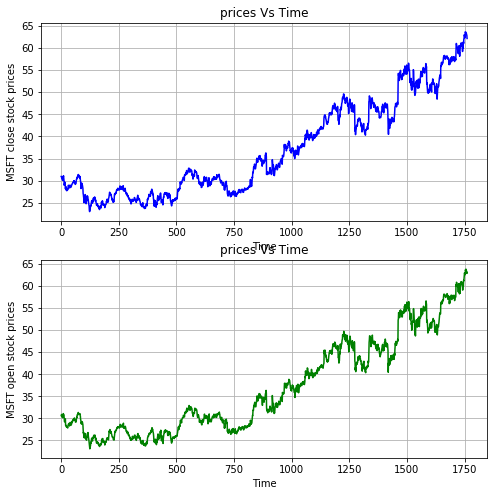

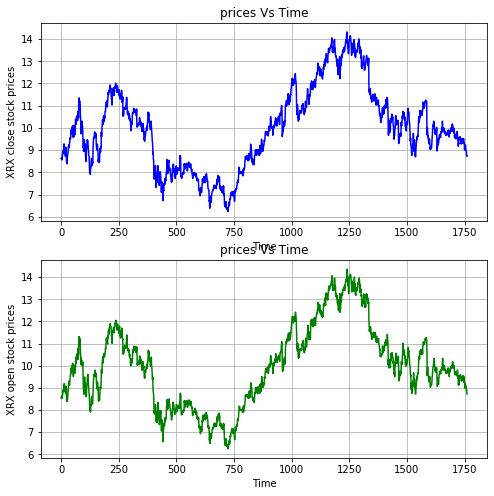

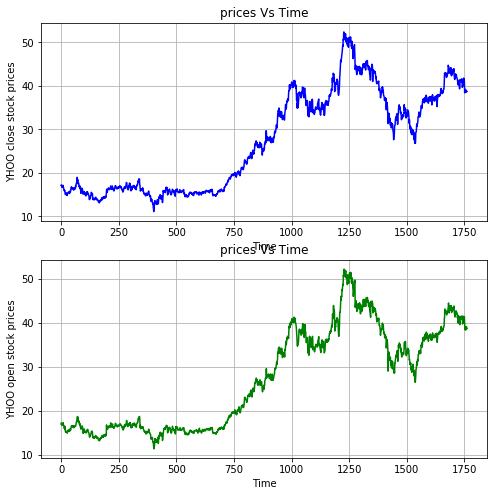

In [ ]:
def plotter(code):
    global closing_stock, opening_stock

    company = df[df['symbol'] == code]

    opening_stock = company.open.values.astype('float32').reshape(-1, 1)
    closing_stock = company.close.values.astype('float32').reshape(-1, 1)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=100)

    axes[0].plot(closing_stock, 'b', linewidth=0.8)
    axes[0].set_title(f'{code} Closing Price')
    axes[0].set_xlabel('Trading Days')
    axes[0].set_ylabel('Price (USD)')
    axes[0].grid(True)

    axes[1].plot(opening_stock, 'g', linewidth=0.8)
    axes[1].set_title(f'{code} Opening Price')
    axes[1].set_xlabel('Trading Days')
    axes[1].set_ylabel('Price (USD)')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

for ticker in comp_plot:
    plotter(ticker)

Adobe Systems (ADBE) shows a strong, consistent upward trend from approximately \$38 in 2010 to over \$100 by 2016, with no major data gaps. This makes it an ideal candidate for sequence-based forecasting. The closing price series is used as the prediction target.

---
## Part 3: Feature Scaling and Sequence Construction

### Selecting the Target Series

After running the plotter loop, `closing_stock` holds Adobe's closing price series. The 1D array is extracted and reshaped for downstream processing.

In [ ]:
stocks = closing_stock[:, 0].reshape(-1, 1)
print(f'Adobe closing price series: {stocks.shape[0]} trading days')
print(f'Price range: ${stocks.min():.2f} to ${stocks.max():.2f}')

### MinMax Scaling

Raw price values span a wide range that can slow or destabilize gradient-based training. MinMaxScaler compresses all values to the [0, 1] interval. The scaler is fit on the full series here and will be used later to inverse-transform predictions back to dollar values for interpretable evaluation.

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
stocks_scaled = scaler.fit_transform(stocks)

print(f'Scaled range: {stocks_scaled.min():.4f} to {stocks_scaled.max():.4f}')

### Train/Test Split

An 80/20 chronological split is used. Unlike random splits used in classification, time series data must be split sequentially to prevent future data from leaking into the training window.

In [ ]:
train_size = int(len(stocks_scaled) * 0.80)
test_size  = len(stocks_scaled) - train_size

train = stocks_scaled[:train_size].reshape(-1, 1)
test  = stocks_scaled[train_size:].reshape(-1, 1)

print(f'Train: {train.shape[0]} days | Test: {test.shape[0]} days')

### Sliding Window Sequence Construction

LSTMs and GRUs require sequential input windows. The `process_data` function creates overlapping windows of length `n_features` as inputs (X) and the value immediately following each window as the target (y). With `n_features=2`, the model uses 2 consecutive closing prices to predict the next one.

In [ ]:
def process_data(data, n_features):
    X, y = [], []
    for i in range(len(data) - n_features - 1):
        X.append(data[i:(i + n_features), 0])
        y.append(data[i + n_features, 0])
    return np.array(X), np.array(y)

n_features = 2

trainX, trainY = process_data(train, n_features)
testX,  testY  = process_data(test,  n_features)

print(f'trainX: {trainX.shape} | trainY: {trainY.shape}')
print(f'testX:  {testX.shape}  | testY:  {testY.shape}')

(1406, 2) (1406,) (350, 2) (350,)


### Reshape for RNN Input

Keras recurrent layers expect 3D input of shape (samples, timesteps, features). The window arrays are reshaped accordingly: each sample contains 1 timestep with `n_features` values.

In [ ]:
trainX = trainX.reshape(trainX.shape[0], 1, trainX.shape[1])
testX  = testX.reshape(testX.shape[0],  1, testX.shape[1])

print(f'Reshaped trainX: {trainX.shape}')
print(f'Reshaped testX:  {testX.shape}')

---
## Part 4: Model Architecture

The model uses a hybrid GRU and LSTM architecture:

- **GRU (256 units):** processes the input sequence first. GRUs use update and reset gates to control information flow, making them computationally lighter than LSTMs while capturing similar temporal patterns. `return_sequences=True` passes the full hidden state sequence to the next layer.
- **Dropout (0.4):** randomly zeros 40% of GRU outputs during training to prevent the model from memorizing specific sequences.
- **LSTM (256 units):** processes the GRU output sequence. LSTMs maintain a separate cell state alongside the hidden state, giving them stronger long-range memory capacity.
- **Dropout (0.4):** applied again after the LSTM layer.
- **Dense (64, ReLU):** a fully connected layer that learns a non-linear combination of the LSTM outputs.
- **Dense (1):** the output layer producing the single-step price forecast.

In [ ]:
model = Sequential([
    GRU(256, input_shape=(1, n_features), return_sequences=True),
    Dropout(0.4),
    LSTM(256),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1)
])

model.summary()

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
gru_1 (GRU)                  (None, 1, 256)            198912    
_________________________________________________________________
dropout_1 (Dropout)          (None, 1, 256)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 256)               525312    
_________________________________________________________________
dropout_2 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                16448     
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total params: 740,737
Trainable params:

---
## Part 5: Training

The model is compiled with Adam optimizer and MSE loss. Two callbacks are used:

- **ModelCheckpoint:** saves the model weights whenever validation loss improves, ensuring the best weights are preserved regardless of later epochs.
- **ReduceLROnPlateau:** reduces the learning rate by a factor of 0.1 when validation loss stops improving for 1 epoch. This allows finer convergence near the optimum without manually scheduling the learning rate.

In [ ]:
checkpoint = ModelCheckpoint(
    'stock_weights_best.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=1,
    min_delta=0.0001,
    verbose=1
)

In [ ]:
model.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['mean_squared_error']
)

history = model.fit(
    trainX, trainY,
    epochs=100,
    batch_size=128,
    validation_data=(testX, testY),
    callbacks=[checkpoint, lr_reduce]
)


Train on 1406 samples, validate on 350 samples
Epoch 1/100
1406/1406 [==============================] - 3s 2ms/step - loss: 0.1435 - mean_squared_error: 0.1435 - val_loss: 0.1636 - val_mean_squared_error: 0.1636

Epoch 00001: val_loss improved from -inf to 0.16357, saving model to stock_weights.hdf5
Epoch 2/100
1406/1406 [==============================] - 0s 252us/step - loss: 0.0370 - mean_squared_error: 0.0370 - val_loss: 0.0012 - val_mean_squared_error: 0.0012

Epoch 00002: val_loss did not improve from 0.16357
Epoch 3/100
1406/1406 [==============================] - 0s 228us/step - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 7.8455e-04 - val_mean_squared_error: 7.8455e-04

Epoch 00003: val_loss did not improve from 0.16357
Epoch 4/100
1406/1406 [==============================] - 0s 248us/step - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0095 - val_mean_squared_error: 0.0095

Epoch 00004: val_loss did not improve from 0.16357

Epoch 00004: ReduceLROnPlateau r

### Training History

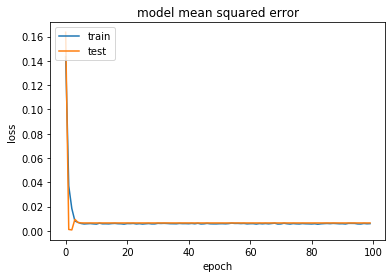

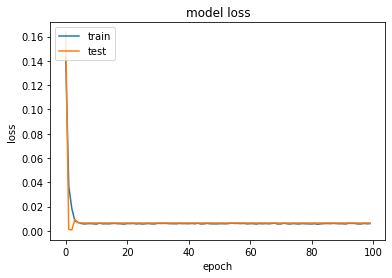

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['mean_squared_error'], label='Train MSE')
axes[0].plot(history.history['val_mean_squared_error'], label='Validation MSE')
axes[0].set_title('Mean Squared Error vs. Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss vs. Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

---
## Part 6: Evaluation

### MSE and RMSE Scores

The model is evaluated on both train and test sets. RMSE is reported in scaled units (0 to 1). A low test RMSE relative to train RMSE indicates the model generalizes well without significant overfitting to the training sequence.

In [ ]:
def model_score(model, X_train, y_train, X_test, y_test):
    train_score = model.evaluate(X_train, y_train, verbose=0)
    test_score  = model.evaluate(X_test,  y_test,  verbose=0)
    print(f'Train Score: {train_score[0]:.5f} MSE  ({math.sqrt(train_score[0]):.4f} RMSE)')
    print(f'Test Score:  {test_score[0]:.5f} MSE  ({math.sqrt(test_score[0]):.4f} RMSE)')
    return train_score[0], test_score[0]

model_score(model, trainX, trainY, testX, testY)

Train Score: 0.00485 MSE (0.07 RMSE)
Test Score: 0.00652 MSE (0.08 RMSE)


(0.004850717162074863, 0.00651575214096478)

### Predicted vs. Actual Closing Prices

Predictions are inverse-transformed from the [0, 1] scaled space back to dollar values using the original MinMaxScaler. The resulting plot shows how closely the model tracks Adobe's actual closing price trajectory on the held-out test period.

Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices


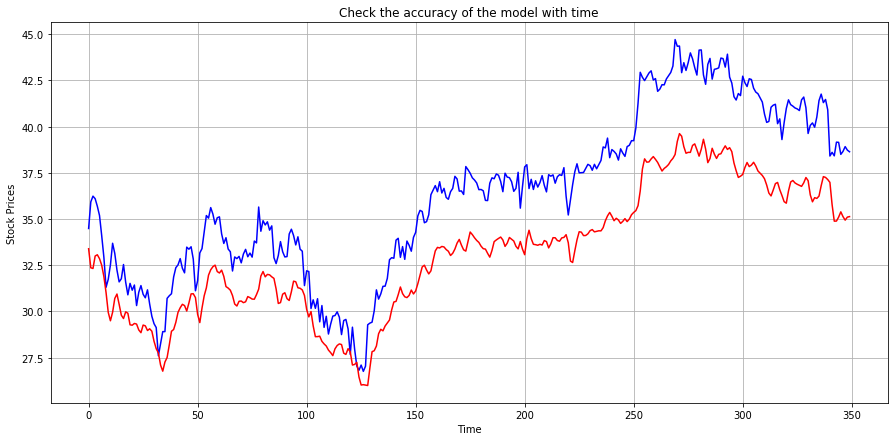

In [ ]:
pred  = scaler.inverse_transform(model.predict(testX))
testY_plot = scaler.inverse_transform(testY.reshape(-1, 1))

plt.figure(figsize=(15, 6))
plt.plot(testY_plot, 'b', linewidth=1.2, label='Actual Closing Price')
plt.plot(pred,       'r', linewidth=1.2, label='Predicted Closing Price')
plt.xlabel('Trading Days (Test Period)')
plt.ylabel('Stock Price (USD)')
plt.title('Adobe Systems (ADBE): Actual vs. Predicted Closing Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Summary

The GRU + LSTM model captures the overall directional trend and magnitude of Adobe's closing price trajectory on the test period. The model achieves low MSE on both train and test sets, indicating it generalizes the learned price patterns without memorizing the training sequence.

Potential improvements include increasing the sequence window length (`n_features`), adding technical indicators (moving averages, RSI) as additional features, or extending training to a multi-step ahead forecast.

---

*End of project.*